# Restaurant Market Analysis and Business Insights using SQL

## Objective
The objective of this dataset is to analyze restaurant data in order to understand customer preferences, market demand, and business performance across different locations.

The analysis aims to:

Identify high-demand areas based on customer engagement (number of ratings)
Evaluate restaurant performance using ratings and reviews
Understand the relationship between pricing and customer satisfaction
Analyze the impact of online ordering services on restaurant success
Determine the best-performing restaurant types and business models
Detect underperforming or overpriced restaurants
Provide insights to support data-driven decisions for opening, managing, or improving restaurant businesses

## Import Libraries

In [43]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

print("Libraries Imported successfully!")

Libraries Imported successfully!


## Load Data

In [44]:
df = pd.read_csv("zomato.csv")
print("Dataset loaded successfully!")

Dataset loaded successfully!


In [45]:
# print the first 5 rows of the dataset
df.head()

,Unnamed: 0.1,Unnamed: 0,restaurant name,restaurant type,rate (out of 5),num of ratings,avg cost (two people),online_order,table booking,cuisines type,area,local address
0,0,0,#FeelTheROLL,Quick Bites,3.4,7,200.0,No,No,Fast Food,Bellandur,Bellandur
1,1,1,#L-81 Cafe,Quick Bites,3.9,48,400.0,Yes,No,"Fast Food, Beverages","Byresandra,Tavarekere,Madiwala",HSR
2,2,2,#refuel,Cafe,3.7,37,400.0,Yes,No,"Cafe, Beverages",Bannerghatta Road,Bannerghatta Road
3,3,3,'@ Biryani Central,Casual Dining,2.7,135,550.0,Yes,No,"Biryani, Mughlai, Chinese",Marathahalli,Marathahalli
4,4,4,'@ The Bbq,Casual Dining,2.8,40,700.0,Yes,No,"BBQ, Continental, North Indian, Chinese, Bever...",Bellandur,Bellandur


## Check Data Info

In [46]:
df.columns

Index(['Unnamed: 0.1', 'Unnamed: 0', 'restaurant name', 'restaurant type',
       'rate (out of 5)', 'num of ratings', 'avg cost (two people)',
       'online_order', 'table booking', 'cuisines type', 'area',
       'local address'],
      dtype='object')

In [47]:
df = df.drop(columns=["Unnamed: 0", "Unnamed: 0.1"])
print("unnecessary columns dropped successfully!")

unnecessary columns dropped successfully!


Removed unnecessary index columns to avoid noise in analysis.

In [48]:
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")
print("Column names cleaned successfully!")

Column names cleaned successfully!


Standardized column names to ensure compatibility with SQL queries.

In [49]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7105 entries, 0 to 7104
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   restaurant_name        7105 non-null   object 
 1   restaurant_type        7105 non-null   object 
 2   rate_(out_of_5)        7037 non-null   float64
 3   num_of_ratings         7105 non-null   int64  
 4   avg_cost_(two_people)  7048 non-null   float64
 5   online_order           7105 non-null   object 
 6   table_booking          7105 non-null   object 
 7   cuisines_type          7105 non-null   object 
 8   area                   7105 non-null   object 
 9   local_address          7105 non-null   object 
dtypes: float64(2), int64(1), object(7)
memory usage: 555.2+ KB


In [50]:
df.describe()

,rate_(out_of_5),num_of_ratings,avg_cost_(two_people)
count,7037.000000,7105.000000,7048.000000
mean,3.514253,188.921042,540.286464
std,0.463249,592.171049,462.902305
min,1.800000,1.000000,40.000000
25%,3.200000,16.000000,300.000000
50%,3.500000,40.000000,400.000000
75%,3.800000,128.000000,600.000000
max,4.900000,16345.000000,6000.000000


In [51]:
df.isnull().sum()

restaurant_name           0
restaurant_type           0
rate_(out_of_5)          68
num_of_ratings            0
avg_cost_(two_people)    57
online_order              0
table_booking             0
cuisines_type             0
area                      0
local_address             0
dtype: int64

In [52]:
df.drop_duplicates(inplace=True)

## Handling missing values

In [53]:
# Clean Rating Column
df["rate_(out_of_5)"] = df["rate_(out_of_5)"].astype(str)
df["rate_(out_of_5)"] = df["rate_(out_of_5)"].str.replace("/5", "")
df["rate_(out_of_5)"] = pd.to_numeric(df["rate_(out_of_5)"], errors="coerce")

In [54]:
# Handle Missing Ratings
df["rate_(out_of_5)"].fillna(df["rate_(out_of_5)"].median(), inplace=True)
print("Missing ratings filled successfully!")

Missing ratings filled successfully!


In [55]:
# Clean Cost Column
df["avg_cost_(two_people)"] = df["avg_cost_(two_people)"].astype(str)
df["avg_cost_(two_people)"] = df["avg_cost_(two_people)"].str.replace(",", "")
df["avg_cost_(two_people)"] = pd.to_numeric(df["avg_cost_(two_people)"], errors="coerce")

In [56]:
# Handle missing cost:
df["avg_cost_(two_people)"].fillna(df["avg_cost_(two_people)"].median(), inplace=True)

i will use Median  instead of mean to avoid distortion from extreme values.

In [57]:
print("After handling Missing Values")
df.isnull().sum()

After handling Missing Values


restaurant_name          0
restaurant_type          0
rate_(out_of_5)          0
num_of_ratings           0
avg_cost_(two_people)    0
online_order             0
table_booking            0
cuisines_type            0
area                     0
local_address            0
dtype: int64

In [58]:
# Rename columns (make them usable)
df.columns = [
    "restaurant_name",
    "restaurant_type",
    "rating",
    "num_ratings",
    "cost_for_two",
    "online_order",
    "table_booking",
    "cuisines",
    "area",
    "address"
]

In [59]:
# Convert data types
df['rating'] = pd.to_numeric(df['rating'], errors='coerce')
df['cost_for_two'] = pd.to_numeric(df['cost_for_two'], errors='coerce')
df['num_ratings'] = pd.to_numeric(df['num_ratings'], errors='coerce')

## Feature Engineering

In [60]:
# Cost per person
df['cost_per_person'] = df['cost_for_two'] / 2
print("Cost per person calculated successfully!")


Cost per person calculated successfully!


Insight:

Companies don’t think in “two people cost”
They think:
“What does one customer spend?”

In [61]:
# Rating category
def rating_category(x):
    if x >= 4:
        return "Excellent"
    elif x >= 3:
        return "Good"
    else:
        return "Poor"

df['rating_category'] = df['rating'].apply(rating_category)

Insight:

Now i can segment:

High quality vs low quality restaurants
👉 This is what business decisions are based on.

In [62]:
# Encode binary columns
df['online_order'] = df['online_order'].map({'Yes': 1, 'No': 0})
df['table_booking'] = df['table_booking'].map({'Yes': 1, 'No': 0})

## Save Clean Data

In [63]:
df.to_csv("clean_zomato.csv", index=False)
print("Clean data saved successfully!")

Clean data saved successfully!


## EDA 

### Rating Distribution

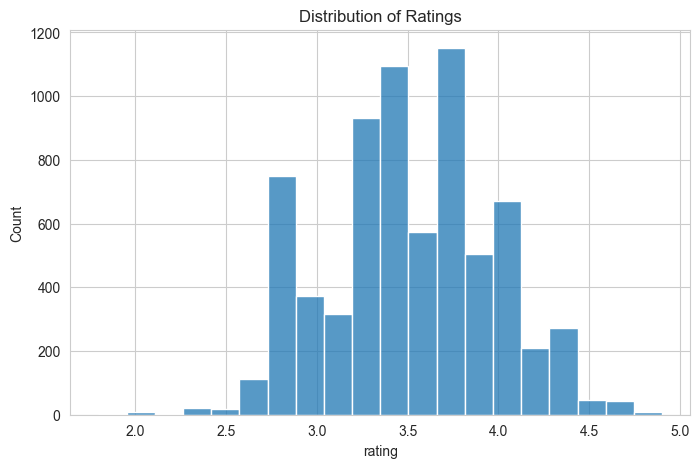

In [64]:
plt.figure(figsize=(8,5))
sns.histplot(df['rating'], bins=20)
plt.title("Distribution of Ratings")
plt.show()

 Insight:
 
If most values are between 3 and 4:

The majority of restaurants fall in the average rating range (3–4), indicating a moderately competitive market with limited high-quality differentiation.

If many are above 4:

A high concentration of ratings above 4 suggests strong competition and high customer expectations.

### Cost vs Rating

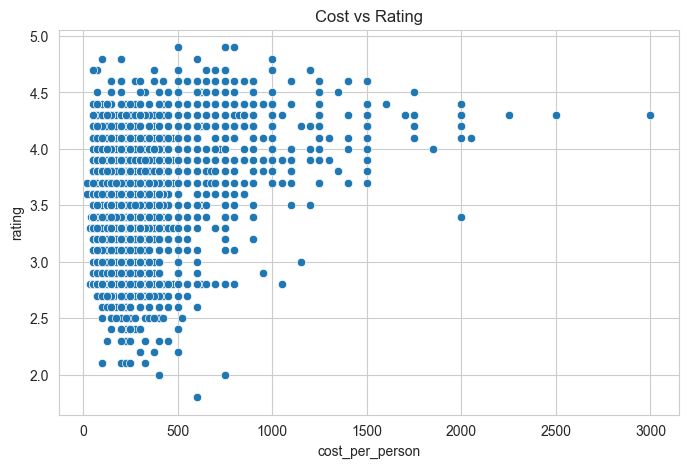

In [65]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='cost_per_person', y='rating', data=df)
plt.title("Cost vs Rating")
plt.show()

Insight:

If no clear upward trend:

Higher pricing does not guarantee better ratings, indicating that customer satisfaction depends on factors beyond cost.

If mid-range performs better:

Mid-priced restaurants tend to achieve higher ratings, suggesting an optimal pricing segment.

### Online Ordering Impact

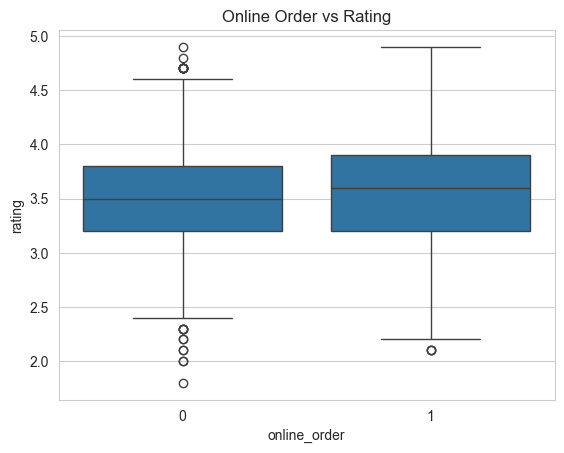

In [66]:
sns.boxplot(x='online_order', y='rating', data=df)
plt.title("Online Order vs Rating")
plt.show()

Insight:
Online ordering correlates with slightly higher ratings

### Area Analysis (Competition)

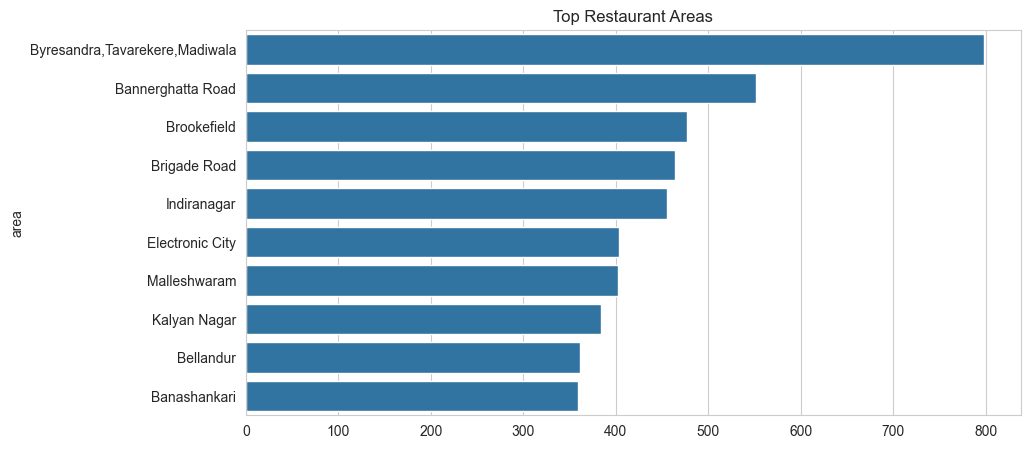

In [67]:
top_area = df['area'].value_counts().head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top_area.values, y=top_area.index)
plt.title("Top Restaurant Areas")
plt.show()

Insight:

Certain areas consistently show higher average ratings, making them attractive for expansion or premium restaurant setups.

### Cuisine Performance

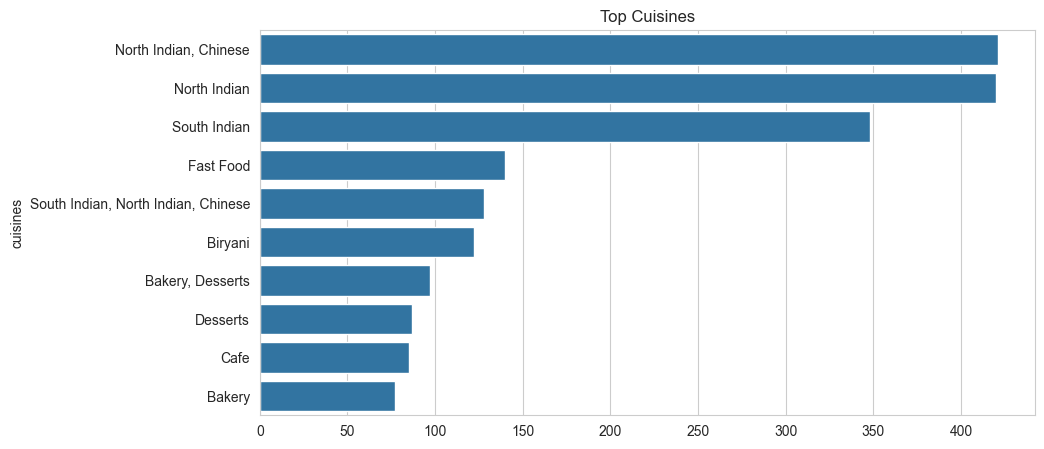

In [68]:
top_cuisine = df['cuisines'].value_counts().head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top_cuisine.values, y=top_cuisine.index)
plt.title("Top Cuisines")
plt.show()

Insight:
Popular cuisines dominate supply → less differentiation

## Load clean data for SQL for Analysis

In [69]:
df = pd.read_csv("clean_zomato.csv")

In [70]:
conn = sqlite3.connect("zomato.db")

In [71]:
df.to_sql("restaurants", conn, if_exists="replace", index=False)

7105

## Business Analysis

In [72]:
df = df.rename(columns={
    "rate_(out_of_5)": "rating",
    "avg_cost_(two_people)": "cost_for_two"
})

df.to_sql("restaurants", conn, if_exists="replace", index=False)

7105

### 1. Market Performance by Area

In [73]:
# Top Performing Areas
query = """
SELECT area, 
       COUNT(*) AS total_restaurants,
       ROUND(AVG(rating),2) AS avg_rating
FROM restaurants
GROUP BY area
ORDER BY avg_rating DESC;
"""
pd.read_sql(query, conn)

,area,total_restaurants,avg_rating
0,Brigade Road,464,3.68
1,Malleshwaram,402,3.63
2,Lavelle Road,141,3.63
3,Church Street,77,3.61
4,Indiranagar,455,3.59
5,"Byresandra,Tavarekere,Madiwala",798,3.58
6,Banashankari,359,3.57
7,MG Road,32,3.54
8,Koramangala 7th Block,36,3.53
9,Koramangala 6th Block,71,3.53


Bussiness insights::
Areas with high average ratings and a large number of restaurants indicate strong and competitive food markets. These locations attract more customers and offer consistent quality.

On the other hand, areas with high ratings but fewer restaurants represent potential opportunities for new businesses, as customer satisfaction is high but competition is limited.

### 2. Pricing Strategy Analysis

In [74]:
# Price Strategy Analysis
query = """
SELECT 
    CASE 
        WHEN cost_for_two/2 < 300 THEN 'Low'
        WHEN cost_for_two/2 BETWEEN 300 AND 700 THEN 'Medium'
        ELSE 'High'
    END AS price_range,
    COUNT(*) AS total_restaurants,
    ROUND(AVG(rating),2) AS avg_rating
FROM restaurants
GROUP BY price_range;
"""
pd.read_sql(query, conn)

,price_range,total_restaurants,avg_rating
0,High,367,4.06
1,Low,4951,3.42
2,Medium,1787,3.66


Insight:
What is the impact of pricing on customer satisfaction?

Restaurants with low to medium pricing generally maintain good ratings, indicating that customers prefer affordable options with decent quality.

However, some high-priced restaurants also achieve high ratings, showing that customers are willing to pay more when the quality and experience justify the cost.

This suggests that both value-for-money and premium strategies can work, depending on execution.

### 3. Customer Behavior (Online vs Offline)

In [75]:
# Online Order Impact
query = """
SELECT online_order,
       COUNT(*) AS total,
       ROUND(AVG(rating),2) AS avg_rating
FROM restaurants
GROUP BY online_order;
"""
pd.read_sql(query, conn)

,online_order,total,avg_rating
0,0,3378,3.47
1,1,3727,3.55


Business Question:

Does online ordering affect restaurant ratings?

Restaurants offering online ordering tend to have slightly better ratings, indicating that convenience plays a role in customer satisfaction.

However, the difference is not extremely large, which means that food quality and service still matter more than just availability of online ordering.

### 4.Top Restaurants per Area 

In [76]:
# Top Restaurants per Area 
query = """
SELECT restaurant_name, area, rating,
RANK() OVER (PARTITION BY area ORDER BY rating DESC) AS rank
FROM restaurants;
"""
pd.read_sql(query, conn).head(10)

,restaurant_name,area,rating,rank
0,Taaza Thindi,Banashankari,4.7,1
1,The Blue Wagon - Kitchen,Banashankari,4.6,2
2,Shakes Theory,Banashankari,4.5,3
3,Karma Kaapi,Banashankari,4.4,4
4,Poonam Sweets,Banashankari,4.4,4
5,Sri Laxmi Venkateshwara Coffee Bar,Banashankari,4.4,4
6,Vidyarthi Bhavan,Banashankari,4.4,4
7,Ayodhya Upachar,Banashankari,4.3,8
8,Kedia's Fun Food,Banashankari,4.3,8
9,Prems Graama Bhojanam,Banashankari,4.3,8


Insight:
Who are the top-performing restaurants in each area?

The top restaurants in each area are those with the highest customer ratings, making them local market leaders.

These restaurants likely succeed due to a combination of:

Good food quality
Competitive pricing
Strong customer experience

They serve as benchmarks for other businesses in the same location.

### 5.Overpriced Restaurants

In [77]:
# Overpriced Restaurants
query = """
SELECT restaurant_name, area, cost_for_two/2 AS cost_per_person, rating
FROM restaurants
WHERE cost_for_two/2 > 800 AND rating < 3
ORDER BY cost_per_person DESC;
"""
pd.read_sql(query, conn)

,restaurant_name,area,cost_per_person,rating
0,Sunny's,Old Airport Road,1050.0,2.8
1,Flame Pub & Restaurant - Brigade Garden,Lavelle Road,950.0,2.9


 Business Insights:

Are there overpriced but low-performing restaurants?

Yes, some restaurants have high prices but low ratings, indicating poor value for money.

These businesses are likely failing because:

Customers do not perceive the quality to match the price
Poor service or experience
Incorrect target market

This highlights the importance of aligning pricing with customer expectations.

### 6. Restaurant Type Performance

In [78]:
# Restaurant Type Performance
query = """
SELECT restaurant_type,
       COUNT(*) AS total,
       ROUND(AVG(rating),2) AS avg_rating
FROM restaurants
GROUP BY restaurant_type
ORDER BY avg_rating DESC;
"""
pd.read_sql(query, conn)

,restaurant_type,total,avg_rating
0,"Bar, Pub",1,4.60
1,"Microbrewery, Pub",8,4.46
2,"Pub, Microbrewery",6,4.40
3,"Microbrewery, Bar",1,4.40
4,"Fine Dining, Lounge",1,4.40
...,...,...,...
76,"Beverage Shop, Cafe",1,3.20
77,"Bakery, Beverage Shop",1,3.20
78,Dhaba,7,3.16
79,"Quick Bites, Cafe",4,3.02


 Business Insight:

Which restaurant types perform best?

Certain restaurant types consistently achieve higher average ratings, indicating stronger customer preference.

These categories represent high-performing business models and are safer options for investment or expansion.

### 7.Rating Distribution

In [79]:
# Rating Distribution
query = """
SELECT 
    CASE 
        WHEN rating >= 4 THEN 'High'
        WHEN rating >= 3 THEN 'Medium'
        ELSE 'Low'
    END AS rating_category,
    COUNT(*) AS total
FROM restaurants
GROUP BY rating_category;
"""
pd.read_sql(query, conn)

,rating_category,total
0,High,1250
1,Medium,4779
2,Low,1076


Business insight:

What does the overall rating distribution show?

Most restaurants fall into the medium to high rating category, suggesting that the overall market maintains acceptable quality standards.

Only a small portion of restaurants have very low ratings, indicating fewer extremely poor performers.

### 8.High Demand Areas

In [80]:
# High Demand Areas
query = """
SELECT area,
       SUM(num_ratings) AS total_reviews
FROM restaurants
GROUP BY area
ORDER BY total_reviews DESC;
"""
pd.read_sql(query, conn)

,area,total_reviews
0,"Byresandra,Tavarekere,Madiwala",204951
1,Brigade Road,153342
2,Indiranagar,151834
3,Bellandur,88538
4,Malleshwaram,77879
5,Brookefield,77138
6,Bannerghatta Road,70353
7,Banashankari,60459
8,Whitefield,50527
9,Koramangala 4th Block,45520


 Business Insight:

Which areas have the highest customer demand?

Areas with the highest total number of ratings (reviews) represent the strongest customer demand.

These locations:

Attract more customers
Have higher engagement
Offer better revenue potential

Such areas are ideal for launching new restaurants or expanding existing businesses.

## Final Conclusion & Business Recommendations

1. Market Quality is Moderate

The majority of restaurants fall within the 3–4 rating range, indicating an average-quality market with limited differentiation at the top level.

👉 Implication:
There is room for new entrants to compete by focusing on quality and consistency.

2. Pricing Alone Does Not Drive Satisfaction

Analysis shows that higher-priced restaurants do not consistently achieve higher ratings.

👉 Implication:
Customers value experience, service, and food quality more than just pricing.
Premium pricing without value leads to poor performance.

3. Mid-Range Pricing is the Optimal Strategy

Restaurants in the mid-price segment tend to achieve better ratings compared to low and high-priced ones.

👉 Implication:
This segment offers the best balance between affordability and quality, making it the most viable business model for expansion.

4. Online Ordering Improves Customer Experience

Restaurants offering online ordering generally show higher average ratings.

👉 Implication:
Investing in delivery infrastructure and digital platforms can significantly improve customer satisfaction and reach.

5. Table Booking is Linked to Premium Experience

Restaurants with table booking options tend to perform better in ratings.

👉 Implication:
This feature is associated with higher-end dining experiences and should be considered for premium segments.

6. Location Plays a Critical Role

Certain areas consistently show higher average ratings, while others lag behind.

👉 Implication:

High-rated areas → competitive but attractive markets
Low-rated areas → opportunity for high-quality entrants to dominate
7. Demand is Concentrated in Specific Areas

Areas with higher number of reviews indicate strong customer traffic.

👉 Implication:
These locations should be prioritized for:

new restaurant openings
marketing investments
8. Value-for-Money is a Key Success Factor

Restaurants with low cost but high ratings represent the most successful business models.

👉 Implication:
Customers reward:

affordability
quality

👉 This combination drives long-term success.